# Solutions: Case Study — Bank LGD Production System

**Module**: Production & Deployment | **Notebook 06 Solutions**  
**Level**: Advanced (Capstone)

---

These are complete solutions for all exercises in Notebook 06.

## Setup

Re-run the setup and core model fitting from the main notebook.

In [1]:
# Standard libraries
import json
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# PanelBox imports
# Helper utilities
import sys

# Scipy for backtransformation
from scipy.special import expit

from panelbox.gmm import DifferenceGMM
from panelbox.models.static.pooled_ols import PooledOLS
from panelbox.models.static.random_effects import RandomEffects
from panelbox.production import ModelRegistry, PanelPipeline

sys.path.insert(0, str(Path("..") / "utils"))
from evaluation_helpers import mae, rmse

# Visualization configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
TABLES_DIR = OUTPUT_DIR / "tables"
REGISTRY_DIR = OUTPUT_DIR / "registry" / "lgd_production"

for d in [FIGURES_DIR, MODELS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete!")

Setup complete!


In [2]:
# Load data
df_lgd = pd.read_csv(DATA_DIR / "bank_lgd.csv")
df_new_bank = pd.read_csv(DATA_DIR / "new_bank_data.csv")

# Train/Test split
df_train = df_lgd[df_lgd["month"] <= 12].copy()
df_test = df_lgd[df_lgd["month"] > 12].copy()

print(f"Training: {len(df_train)} obs, Test: {len(df_test)} obs")
print(f"New bank data: {len(df_new_bank)} obs")

Training: 2400 obs, Test: 600 obs
New bank data: 150 obs


In [3]:
# Fit the baseline models (needed by exercises)
# PooledOLS
pipe_ols = PanelPipeline(
    model_class=PooledOLS,
    model_params={
        "formula": "lgd_logit ~ saldo_real + pib_growth + selic + collateral_ratio",
        "entity_col": "contract_id",
        "time_col": "month",
    },
    name="LGD PooledOLS",
)
pipe_ols.fit(df_train)

# GMM
pipe_gmm = PanelPipeline(
    model_class=DifferenceGMM,
    model_params={
        "dep_var": "lgd_logit",
        "lags": 1,
        "exog_vars": ["saldo_real", "pib_growth", "selic", "collateral_ratio"],
        "id_var": "contract_id",
        "time_var": "month",
        "gmm_max_lag": 3,
        "collapse": True,
        "two_step": True,
        "robust": True,
        "time_dummies": False,
    },
    name="LGD Arellano-Bond",
)
pipe_gmm.fit(df_train)

# Compute baseline metrics
preds_ols = pipe_ols.predict(df_test)
ols_rmse = rmse(df_test["lgd_logit"].values, preds_ols)
ols_mae = mae(df_test["lgd_logit"].values, preds_ols)

preds_gmm = pipe_gmm.predict(df_test)
valid_gmm = ~np.isnan(preds_gmm)
gmm_rmse = rmse(df_test.loc[valid_gmm, "lgd_logit"].values, preds_gmm[valid_gmm])
gmm_mae = mae(df_test.loc[valid_gmm, "lgd_logit"].values, preds_gmm[valid_gmm])

print(f"PooledOLS - RMSE: {ols_rmse:.4f}, MAE: {ols_mae:.4f}")
print(f"GMM       - RMSE: {gmm_rmse:.4f}, MAE: {gmm_mae:.4f}")

PooledOLS - RMSE: 0.8431, MAE: 0.6726
GMM       - RMSE: 0.4344, MAE: 0.3521


---

## Exercise 1 (Easy): Add Random Effects Model

**Task**: Add a `RandomEffects` model to the comparison. Does it improve over PooledOLS?

In [4]:
# Exercise 1 Solution: Random Effects model

pipe_re = PanelPipeline(
    model_class=RandomEffects,
    model_params={
        "formula": "lgd_logit ~ saldo_real + pib_growth + selic + collateral_ratio",
        "entity_col": "contract_id",
        "time_col": "month",
    },
    name="LGD Random Effects",
)
pipe_re.fit(df_train)

print("=== Random Effects ===")
print(pipe_re.results.summary())

=== Random Effects ===
                   Random Effects (GLS) Estimation Results                    
Formula: lgd_logit ~ saldo_real + pib_growth + selic + collateral_ratio
Model:   Random Effects (GLS)
------------------------------------------------------------------------------
No. Observations:               2,400
No. Entities:                     200
No. Time Periods:                  12
Degrees of Freedom:             2,395
R-squared:                     0.1684
Adj. R-squared:                0.1671
R-squared (within):            0.1465
R-squared (between):           0.2073
R-squared (overall):           0.1684
Standard Errors:            nonrobust
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
Intercept            5.4908      0.2233  24.594  0.0000    5.0530    5.9286 ***
saldo_real           0.1872      0.0386   4.843  0.0000    0.1114    0.2630 ***
pib_growth      

In [5]:
# Predict on test set
preds_re = pipe_re.predict(df_test)
re_rmse = rmse(df_test["lgd_logit"].values, preds_re)
re_mae = mae(df_test["lgd_logit"].values, preds_re)

print(f"Random Effects - RMSE: {re_rmse:.4f}, MAE: {re_mae:.4f}")
print()

# Compare with PooledOLS
print("=== Comparison ===")
comparison = pd.DataFrame(
    {
        "Model": ["PooledOLS", "Random Effects", "GMM"],
        "RMSE": [ols_rmse, re_rmse, gmm_rmse],
        "MAE": [ols_mae, re_mae, gmm_mae],
    }
).set_index("Model")
display(comparison.round(4))

print()
if re_rmse < ols_rmse:
    improvement = (ols_rmse - re_rmse) / ols_rmse * 100
    print(f"Random Effects improves over PooledOLS by {improvement:.1f}% RMSE")
else:
    print("Random Effects does NOT improve over PooledOLS in RMSE")

Random Effects - RMSE: 0.8471, MAE: 0.6732

=== Comparison ===


,RMSE,MAE
Model,,
PooledOLS,0.8431,0.6726
Random Effects,0.8471,0.6732
GMM,0.4344,0.3521



Random Effects does NOT improve over PooledOLS in RMSE


> **Note**: Random Effects is a compromise between PooledOLS and Fixed Effects. It models entity heterogeneity as random draws, which can improve efficiency. However, if the entity effects are correlated with regressors (which is common), Fixed Effects is more appropriate. The Hausman test can be used to decide.

---

## Exercise 2 (Medium): GMM Forecasting

**Task**: Use `forecast()` to predict LGD 3 months ahead for 5 contracts. Compare with actual values.

In [6]:
# Exercise 2 Solution: GMM Forecasting

# Step 1: Select 5 contracts from training data
forecast_contracts = df_train["contract_id"].unique()[:5]
print("Forecast contracts:", list(forecast_contracts))

# Step 2: Build last_obs dictionary
last_obs = {}
for cid in forecast_contracts:
    last_val = df_train[df_train["contract_id"] == cid]["lgd_logit"].iloc[-1]
    last_obs[cid] = [last_val]

print("\nLast observed values:")
for cid, vals in last_obs.items():
    print(f"  Contract {cid}: lgd_logit = {vals[0]:.4f}")

Forecast contracts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Last observed values:
  Contract 1: lgd_logit = 3.3482
  Contract 2: lgd_logit = 2.6626
  Contract 3: lgd_logit = 3.8242
  Contract 4: lgd_logit = 3.5528
  Contract 5: lgd_logit = 3.5520


In [7]:
# Step 3: Build future_exog DataFrame
# Use average values from training data as baseline scenario
avg_saldo = df_train["saldo_real"].mean()
avg_pib = df_train["pib_growth"].mean()
avg_selic = df_train["selic"].mean()
avg_collateral = df_train["collateral_ratio"].mean()

future_rows = []
for cid in forecast_contracts:
    for step in range(1, 4):
        future_rows.append(
            {
                "contract_id": cid,
                "month": 12 + step,
                "saldo_real": avg_saldo,
                "pib_growth": avg_pib,
                "selic": avg_selic,
                "collateral_ratio": avg_collateral,
            }
        )

df_future = pd.DataFrame(future_rows)
print(f"Future exogenous data: {len(df_future)} rows")
display(df_future.head(6))

Future exogenous data: 15 rows


,contract_id,month,saldo_real,pib_growth,selic,collateral_ratio
0,1,13,9.88,2.3116,9.8855,0.6167
1,1,14,9.88,2.3116,9.8855,0.6167
2,1,15,9.88,2.3116,9.8855,0.6167
3,2,13,9.88,2.3116,9.8855,0.6167
4,2,14,9.88,2.3116,9.8855,0.6167
5,2,15,9.88,2.3116,9.8855,0.6167


In [8]:
# Step 4: Generate forecasts
forecasts = pipe_gmm.forecast(
    last_obs=last_obs,
    future_exog=df_future,
    steps=3,
)

print("Forecast Results:")
display(forecasts)

# Compare with actual values from test set
print("\nComparison with actual values:")
for cid in forecast_contracts:
    actual = df_test[df_test["contract_id"] == cid]["lgd_logit"].values
    fc = forecasts[forecasts["contract_id"] == cid]["forecast"].values

    n_compare = min(len(actual), len(fc))
    if n_compare > 0:
        fc_rmse = rmse(actual[:n_compare], fc[:n_compare])
        print(f"  Contract {cid}: Forecast RMSE = {fc_rmse:.4f}")

Forecast Results:


,contract_id,month,forecast
0,1,13.0,3.1389
1,1,14.0,3.0152
2,1,15.0,2.9420
3,2,13.0,2.7335
4,2,14.0,2.7755
5,2,15.0,2.8003
6,3,13.0,3.4204
7,3,14.0,3.1816
8,3,15.0,3.0405
9,4,13.0,3.2599



Comparison with actual values:
  Contract 1: Forecast RMSE = 0.4042
  Contract 2: Forecast RMSE = 0.4396
  Contract 3: Forecast RMSE = 0.6567
  Contract 4: Forecast RMSE = 0.0569
  Contract 5: Forecast RMSE = 0.9616


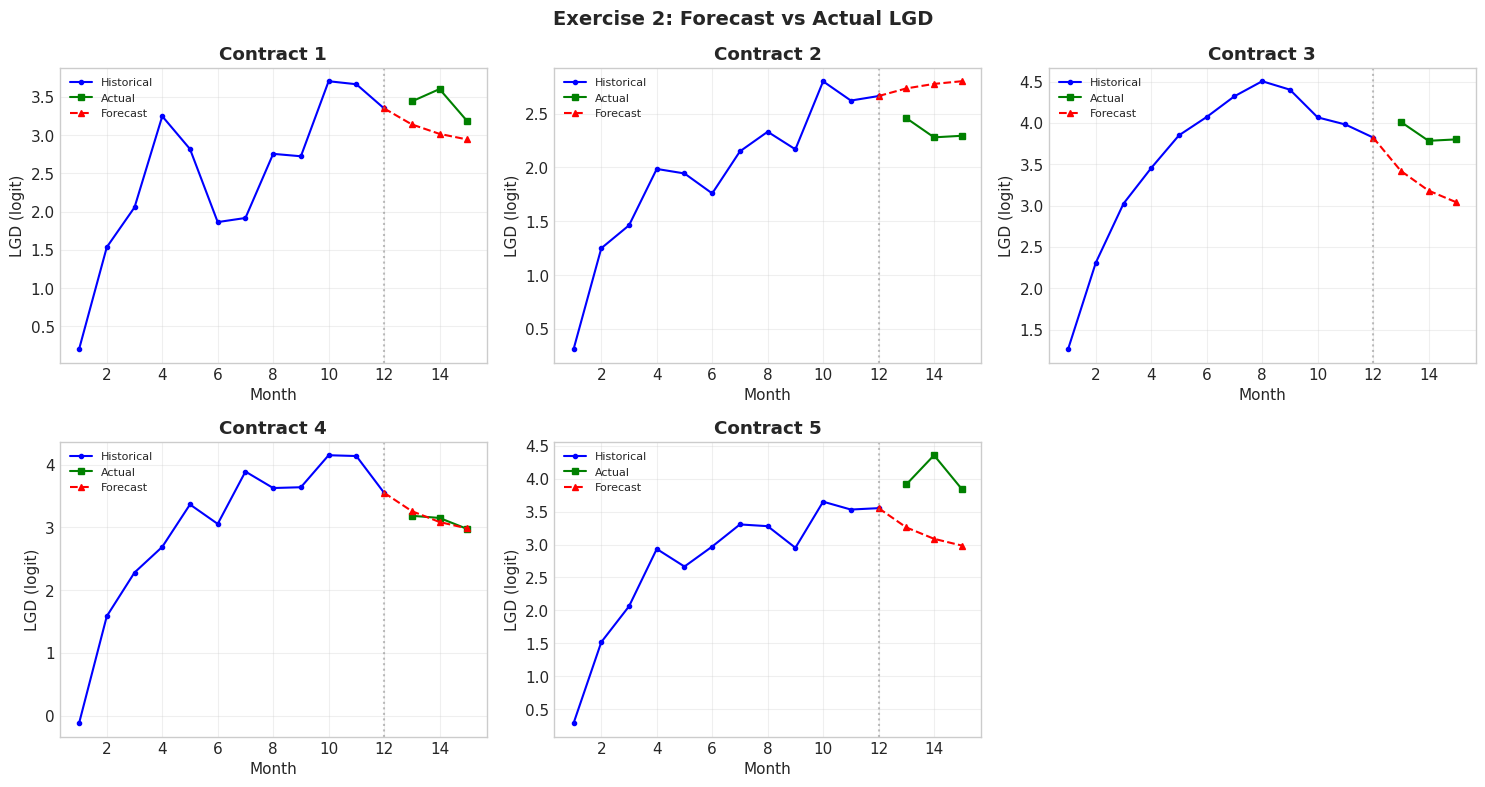

Figure saved.


In [9]:
# Step 5: Plot forecast trajectory
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, cid in enumerate(forecast_contracts):
    ax = axes[i]

    # Historical data
    hist = df_train[df_train["contract_id"] == cid]
    ax.plot(hist["month"], hist["lgd_logit"], "b-o", markersize=3, label="Historical")

    # Actual test data
    actual = df_test[df_test["contract_id"] == cid]
    if len(actual) > 0:
        ax.plot(actual["month"], actual["lgd_logit"], "g-s", markersize=5, label="Actual")

    # Forecasts
    fc = forecasts[forecasts["contract_id"] == cid]
    connect_months = [hist["month"].iloc[-1], *list(fc["month"])]
    connect_vals = [hist["lgd_logit"].iloc[-1], *list(fc["forecast"])]
    ax.plot(connect_months, connect_vals, "r--^", markersize=5, label="Forecast")

    ax.axvline(x=12, color="gray", linestyle=":", alpha=0.5)
    ax.set_title(f"Contract {cid}", fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("LGD (logit)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Empty last subplot
axes[5].set_visible(False)

plt.suptitle("Exercise 2: Forecast vs Actual LGD", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_ex2_forecast_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

> **Key insight**: The GMM forecasts converge to a long-run mean because the AR(1) coefficient is less than 1. This is expected behavior for a stationary process: the further ahead we forecast, the closer predictions get to the unconditional mean.

---

## Exercise 3 (Hard): Backtesting Framework

**Task**: Build expanding-window backtesting: train on months 1-8, predict 9; train on 1-9, predict 10; etc.

In [10]:
# Exercise 3 Solution: Backtesting Framework

gmm_params = pipe_gmm.model_params.copy()

backtest_results = []
min_train_months = 8  # Need enough months for GMM estimation
max_month = df_lgd["month"].max()

print("=== Backtesting Framework ===")
print(
    f"Expanding window: train on months 1-{min_train_months}, predict month {min_train_months + 1}"
)
print(f"Continue until month {max_month}")
print()

for train_end in range(min_train_months, max_month):
    test_month = train_end + 1

    # Training data: months 1 to train_end
    df_bt_train = df_lgd[df_lgd["month"] <= train_end].copy()

    # Test data: need train_end and test_month for lag computation
    df_bt_test = df_lgd[df_lgd["month"].isin([train_end, test_month])].copy()

    try:
        # Re-estimate model
        bt_pipeline = PanelPipeline(
            model_class=DifferenceGMM,
            model_params=gmm_params,
            name=f"BT_m1-{train_end}",
        )
        bt_pipeline.fit(df_bt_train)

        # Predict on test data (need both months for lag)
        preds = bt_pipeline.predict(df_bt_test)

        # Extract predictions for test month only
        test_mask = df_bt_test["month"] == test_month
        preds_test = preds[test_mask.values]
        actual_test = df_bt_test.loc[test_mask, "lgd_logit"].values

        valid = ~np.isnan(preds_test)
        if valid.sum() > 0:
            bt_rmse = rmse(actual_test[valid], preds_test[valid])
            bt_mae_val = mae(actual_test[valid], preds_test[valid])

            backtest_results.append(
                {
                    "train_end": train_end,
                    "test_month": test_month,
                    "n_train_obs": len(df_bt_train),
                    "n_test_valid": int(valid.sum()),
                    "RMSE": bt_rmse,
                    "MAE": bt_mae_val,
                }
            )
            print(
                f"  Train 1-{train_end}, Test {test_month}: RMSE={bt_rmse:.4f}, MAE={bt_mae_val:.4f} ({valid.sum()} valid)"
            )
        else:
            print(f"  Train 1-{train_end}, Test {test_month}: No valid predictions")
    except Exception as e:
        print(f"  Train 1-{train_end}, Test {test_month}: ERROR - {str(e)[:60]}")

bt_df = pd.DataFrame(backtest_results)
print(f"\nBacktesting complete: {len(bt_df)} windows evaluated")

=== Backtesting Framework ===
Expanding window: train on months 1-8, predict month 9
Continue until month 15

  Train 1-8, Test 9: RMSE=0.4272, MAE=0.3456 (200 valid)


  Train 1-9, Test 10: RMSE=0.4069, MAE=0.3346 (200 valid)
  Train 1-10, Test 11: RMSE=0.4219, MAE=0.3281 (200 valid)


  Train 1-11, Test 12: RMSE=0.4067, MAE=0.3271 (200 valid)


  Train 1-12, Test 13: RMSE=0.3961, MAE=0.3171 (200 valid)


  Train 1-13, Test 14: RMSE=0.4545, MAE=0.3652 (200 valid)


  Train 1-14, Test 15: RMSE=0.4163, MAE=0.3377 (200 valid)

Backtesting complete: 7 windows evaluated


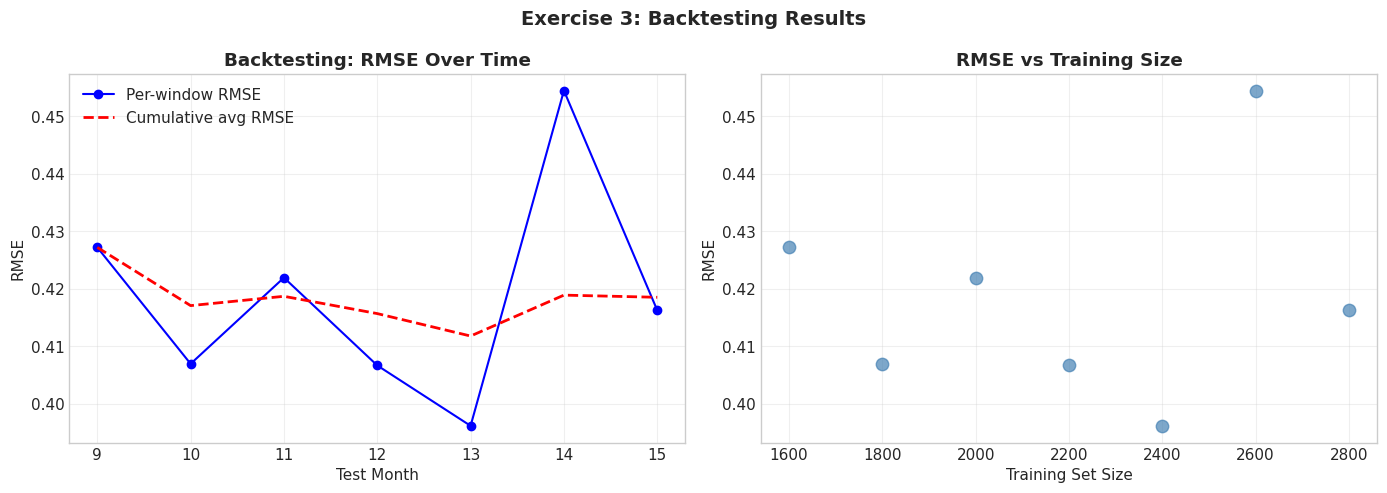

Figure saved.

Backtesting Summary:


,train_end,test_month,n_train_obs,n_test_valid,RMSE,MAE,cumulative_RMSE
0,8,9,1600,200,0.4272,0.3456,0.4272
1,9,10,1800,200,0.4069,0.3346,0.4171
2,10,11,2000,200,0.4219,0.3281,0.4187
3,11,12,2200,200,0.4067,0.3271,0.4157
4,12,13,2400,200,0.3961,0.3171,0.4118
5,13,14,2600,200,0.4545,0.3652,0.4189
6,14,15,2800,200,0.4163,0.3377,0.4185



First half avg RMSE: 0.4187
Second half avg RMSE: 0.4184
Performance appears stable over time.


In [11]:
# Cumulative RMSE and plot
if len(bt_df) > 0:
    bt_df["cumulative_RMSE"] = bt_df["RMSE"].expanding().mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Per-window RMSE
    axes[0].plot(bt_df["test_month"], bt_df["RMSE"], "b-o", markersize=6, label="Per-window RMSE")
    axes[0].plot(
        bt_df["test_month"],
        bt_df["cumulative_RMSE"],
        "r--",
        linewidth=2,
        label="Cumulative avg RMSE",
    )
    axes[0].set_xlabel("Test Month")
    axes[0].set_ylabel("RMSE")
    axes[0].set_title("Backtesting: RMSE Over Time", fontweight="bold")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Training size vs RMSE
    axes[1].scatter(bt_df["n_train_obs"], bt_df["RMSE"], c="steelblue", s=80, alpha=0.7)
    axes[1].set_xlabel("Training Set Size")
    axes[1].set_ylabel("RMSE")
    axes[1].set_title("RMSE vs Training Size", fontweight="bold")
    axes[1].grid(alpha=0.3)

    plt.suptitle("Exercise 3: Backtesting Results", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "06_ex3_backtesting.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved.")

    # Analysis
    print("\nBacktesting Summary:")
    display(bt_df.round(4))

    # Trend analysis
    if len(bt_df) >= 3:
        first_half = bt_df.iloc[: len(bt_df) // 2]["RMSE"].mean()
        second_half = bt_df.iloc[len(bt_df) // 2 :]["RMSE"].mean()
        print(f"\nFirst half avg RMSE: {first_half:.4f}")
        print(f"Second half avg RMSE: {second_half:.4f}")
        if second_half > first_half * 1.1:
            print("Performance appears to degrade over time.")
        else:
            print("Performance appears stable over time.")
else:
    print("No backtesting results to plot.")

> **Key insight**: Expanding-window backtesting reveals whether the model is stable over time or whether there is concept drift. If RMSE increases in later windows, it may indicate that the DGP is changing or that the model is overfitting early patterns.

---

## Exercise 4 (Expert): Automated Production Script

**Task**: Create a function that automates the production scoring workflow.

In [12]:
# Exercise 4 Solution: Automated Production Script


def run_production_scoring(
    config: dict,
    log_file: str = None,
) -> dict:
    """
    Automated production scoring pipeline.

    Parameters
    ----------
    config : dict
        Configuration with keys:
        - data_path: str, path to input CSV
        - registry_path: str, path to model registry
        - output_path: str, path for output predictions CSV
        - historical_avg_lgd: float, for drift check
        - drift_threshold: float, max acceptable drift %
    log_file : str, optional
        Path to log file

    Returns
    -------
    dict
        Results summary
    """
    # Setup logging
    logger = logging.getLogger("lgd_production")
    logger.setLevel(logging.INFO)
    logger.handlers.clear()

    formatter = logging.Formatter("%(asctime)s - %(levelname)s - %(message)s")

    # Console handler
    ch = logging.StreamHandler()
    ch.setFormatter(formatter)
    logger.addHandler(ch)

    # File handler (optional)
    if log_file:
        fh = logging.FileHandler(log_file)
        fh.setFormatter(formatter)
        logger.addHandler(fh)

    result = {"status": "UNKNOWN", "errors": [], "warnings": []}

    try:
        # Step 1: Read configuration
        logger.info("=== LGD Production Scoring ===")
        logger.info(f"Config: {json.dumps(config, default=str)}")

        # Step 2: Load data
        data_path = Path(config["data_path"])
        if not data_path.exists():
            raise FileNotFoundError(f"Data file not found: {data_path}")

        df = pd.read_csv(data_path)
        logger.info(f"Loaded data: {len(df)} rows, {df.shape[1]} columns")
        result["n_input_rows"] = len(df)

        # Step 3: Load latest model from registry
        registry_path = Path(config["registry_path"])
        registry = ModelRegistry(registry_path)
        pipeline = registry.load_latest()
        logger.info(f"Loaded model: {pipeline.name}, fitted at {pipeline.fit_timestamp}")
        result["model_name"] = pipeline.name

        # Step 4: Generate predictions
        preds = pipeline.predict(df)
        valid = ~np.isnan(preds)
        n_valid = int(valid.sum())
        logger.info(f"Generated {n_valid} valid predictions out of {len(preds)} total")
        result["n_predictions"] = n_valid

        if n_valid == 0:
            logger.warning("No valid predictions generated!")
            result["status"] = "WARNING"
            result["warnings"].append("No valid predictions")
            return result

        lgd_preds = expit(preds[valid])

        # Step 5: Validation checks
        # Check LGD range
        if lgd_preds.min() < 0 or lgd_preds.max() > 1:
            result["warnings"].append(
                f"LGD out of [0,1] range: [{lgd_preds.min():.4f}, {lgd_preds.max():.4f}]"
            )
            logger.warning("LGD range violation!")
        else:
            logger.info(f"LGD range check: PASS [{lgd_preds.min():.4f}, {lgd_preds.max():.4f}]")

        # Check drift
        historical_avg = config.get("historical_avg_lgd", 0.5)
        drift_threshold = config.get("drift_threshold", 20.0)
        predicted_avg = float(lgd_preds.mean())
        drift_pct = abs(predicted_avg - historical_avg) / historical_avg * 100

        if drift_pct > drift_threshold:
            result["warnings"].append(
                f"Drift {drift_pct:.1f}% exceeds threshold {drift_threshold}%"
            )
            logger.warning(f"Average LGD drift: {drift_pct:.1f}% (threshold: {drift_threshold}%)")
        else:
            logger.info(f"Drift check: PASS ({drift_pct:.1f}%)")

        result["avg_lgd"] = predicted_avg
        result["drift_pct"] = drift_pct

        # Step 6: Save results
        output_path = Path(config["output_path"])
        output_path.parent.mkdir(parents=True, exist_ok=True)

        output_df = df.copy()
        output_df["lgd_prediction"] = preds
        output_df["lgd_prediction_0_1"] = expit(preds)
        output_df.to_csv(output_path, index=False)
        logger.info(f"Predictions saved to {output_path}")

        result["status"] = "WARNING" if result["warnings"] else "SUCCESS"
        result["output_path"] = str(output_path)

    except Exception as e:
        logger.error(f"FATAL ERROR: {e!s}")
        result["status"] = "ERROR"
        result["errors"].append(str(e))

    logger.info(f"Final status: {result['status']}")
    return result


print("Production scoring function defined.")

Production scoring function defined.


In [13]:
# Test the production scoring function
historical_avg = float(expit(df_train["lgd_logit"]).mean())

config = {
    "data_path": str(DATA_DIR / "new_bank_data.csv"),
    "registry_path": str(REGISTRY_DIR),
    "output_path": str(TABLES_DIR / "06_ex4_production_output.csv"),
    "historical_avg_lgd": historical_avg,
    "drift_threshold": 20.0,
}

print("Running production scoring...")
print()
result = run_production_scoring(config)
print()
print("=== Result ===")
for k, v in result.items():
    print(f"  {k}: {v}")

2026-02-22 16:12:10,018 - INFO - === LGD Production Scoring ===


2026-02-22 16:12:10,019 - INFO - Config: {"data_path": "../data/new_bank_data.csv", "registry_path": "../outputs/registry/lgd_production", "output_path": "../outputs/tables/06_ex4_production_output.csv", "historical_avg_lgd": 0.8507659944761419, "drift_threshold": 20.0}


2026-02-22 16:12:10,020 - INFO - Loaded data: 150 rows, 7 columns


2026-02-22 16:12:10,021 - INFO - Loaded model: LGD Arellano-Bond, fitted at 2026-02-22T16:09:50.193212


2026-02-22 16:12:10,022 - INFO - Generated 100 valid predictions out of 150 total


2026-02-22 16:12:10,023 - INFO - LGD range check: PASS [0.5094, 0.9425]


2026-02-22 16:12:10,023 - INFO - Drift check: PASS (7.7%)


2026-02-22 16:12:10,026 - INFO - Predictions saved to ../outputs/tables/06_ex4_production_output.csv


2026-02-22 16:12:10,026 - INFO - Final status: SUCCESS


Running production scoring...


=== Result ===
  status: SUCCESS
  errors: []
  warnings: []
  n_input_rows: 150
  model_name: LGD Arellano-Bond
  n_predictions: 100
  avg_lgd: 0.7853169596926872
  drift_pct: 7.692953786164762
  output_path: ../outputs/tables/06_ex4_production_output.csv


> **Production deployment note**: In a real system, this function would be wrapped in a standalone `.py` script and scheduled via cron, Airflow, or similar. The logging would go to a centralized log management system, and the output CSV would be consumed by downstream processes (risk reporting, capital calculations, etc.).

---

## Summary

| Exercise | Key Concepts |
|----------|-------------|
| **1 (Easy)** | RandomEffects pipeline, model comparison, RMSE/MAE |
| **2 (Medium)** | `forecast()` for multi-step ahead, AR(1) dynamics, trajectory plots |
| **3 (Hard)** | Expanding-window backtesting, model stability, cumulative RMSE |
| **4 (Expert)** | Production automation, logging, validation checks, end-to-end pipeline |